In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Load and map baseline data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df.rename(columns={'customerID': 'user_id', 'MonthlyCharges': 'monthly_spend'})

# 2. Synthesize dates and RFM proxies
mock_today = pd.to_datetime('2024-01-01')
tenure_days = df['tenure'] * 30.436875
df['signup_date'] = mock_today - pd.to_timedelta(tenure_days, unit='D')

# Add variance to cancellation dates and last active dates so Recency isn't identical for everyone
np.random.seed(42)
churn_mask = df['Churn'] == 'Yes'
df.loc[churn_mask, 'cancel_date'] = mock_today - pd.to_timedelta(np.random.randint(1, 90, size=churn_mask.sum()), unit='D')
df.loc[~churn_mask, 'cancel_date'] = pd.NaT

# Active users were seen recently (0-30 days ago); Churned users' last activity was their cancel date
df['last_active_date'] = np.where(
    churn_mask, 
    df['cancel_date'], 
    mock_today - pd.to_timedelta(np.random.randint(0, 30, size=len(df)), unit='D')
)

# Proxy Frequency: 1 event per month of tenure (minimum 1)
df['event_count'] = np.maximum(df['tenure'], 1) 

df = df.drop(columns=['tenure'])

In [3]:
# Create a copy for RFM processing
rfm_df = df[['user_id', 'last_active_date', 'event_count', 'monthly_spend']].copy()

# Recency: Days since last active
rfm_df['Recency'] = (mock_today - rfm_df['last_active_date']).dt.days

# Frequency: Total usage events (or billing cycles)
rfm_df['Frequency'] = rfm_df['event_count']

# Monetary: Monthly recurring spend
rfm_df['Monetary'] = rfm_df['monthly_spend']

# Drop intermediate columns to leave purely the RFM matrix
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

print("--- RFM Feature Summary ---")
display(rfm_features.describe().round(2))

--- RFM Feature Summary ---


,Recency,Frequency,Monetary
count,7043.00,7043.00,7043.00
mean,22.49,32.37,64.76
std,19.82,24.56,30.09
min,0.00,1.00,18.25
25%,9.00,9.00,35.50
50%,18.00,29.00,70.35
75%,27.00,55.00,89.85
max,89.00,72.00,118.75


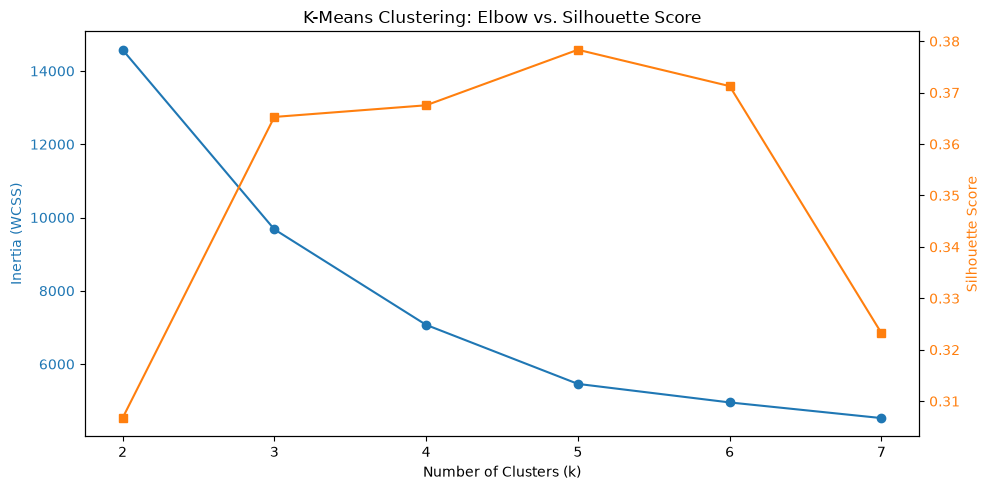

In [4]:
# Scale features because R, F, and M operate on entirely different numerical scales
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

inertia = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot Elbow Curve and Silhouette Scores side-by-side
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(k_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(k_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Clustering: Elbow vs. Silhouette Score')
fig.tight_layout()  
plt.show()

--- Business Segment Profiles ---


,Avg_Recency_Days,Avg_Frequency,Avg_Monetary_Spend,Customer_Count,Pct_of_Base
Cluster,,,,,
2,15.42,51.70,88.87,2645,37.6%
0,62.79,16.24,76.44,1038,14.7%
1,15.60,22.14,42.18,3360,47.7%


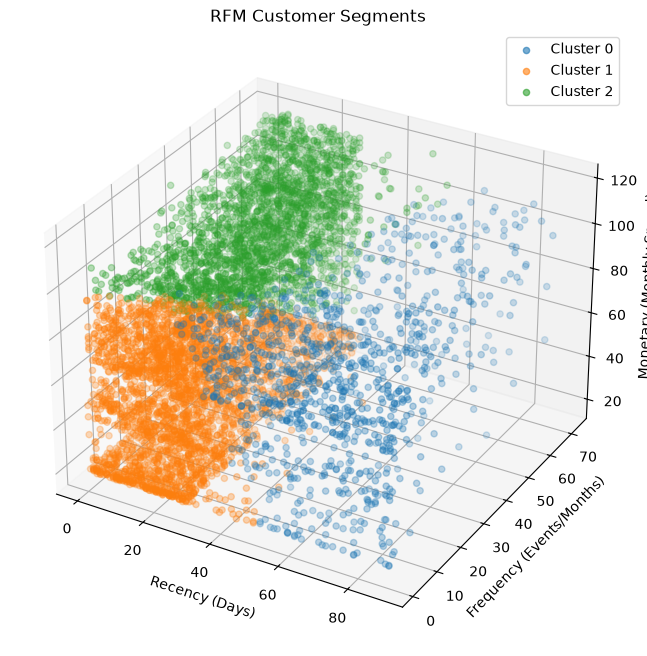

In [5]:
# Fit final K-Means with the chosen k (e.g., 3)
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_df['Cluster'] = final_kmeans.fit_predict(rfm_scaled)

# Calculate segment averages to assign business meaning
cluster_summary = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

# Flatten MultiIndex columns for readability
cluster_summary.columns = ['Avg_Recency_Days', 'Avg_Frequency', 'Avg_Monetary_Spend', 'Customer_Count']
cluster_summary['Pct_of_Base'] = (cluster_summary['Customer_Count'] / len(rfm_df) * 100).round(1).astype(str) + '%'

print("--- Business Segment Profiles ---")
display(cluster_summary.sort_values('Avg_Monetary_Spend', ascending=False))

# Visualize the clusters on a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Map clusters to colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for cluster_id in range(optimal_k):
    cluster_data = rfm_df[rfm_df['Cluster'] == cluster_id]
    ax.scatter(
        cluster_data['Recency'], 
        cluster_data['Frequency'], 
        cluster_data['Monetary'], 
        c=colors[cluster_id], 
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=20
    )

ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Events/Months)')
ax.set_zlabel('Monetary (Monthly Spend)')
plt.title('RFM Customer Segments')
plt.legend()
plt.show()